In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')


In [4]:
!pip install kaggle
from google.colab import files
files.upload()  # upload only your kaggle.json key file (tiny file)

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloads directly to Colab at full speed
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip brain-tumor-mri-dataset.zip -d /content/brain_tumor

Streaming output truncated to the last 5000 lines.
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/brain_tumor/Training/glioma/Tr-gl_290.jpg  
  inflating: /content/brain

In [5]:
dataset = "/content/brain_tumor"

In [6]:
import os
print(os.listdir(dataset))

['Testing', 'Training']


In [7]:

train_path = "/content/brain_tumor/Training"
test_path = "/content/brain_tumor/Testing"
print(os.listdir("/content/brain_tumor/Training"))
print(os.listdir("/content/brain_tumor/Testing"))

['glioma', 'notumor', 'pituitary', 'meningioma']
['glioma', 'notumor', 'pituitary', 'meningioma']


In [8]:
from torchvision import datasets , transforms
from torch.utils.data import DataLoader , Dataset
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485 , 0.456 , 0.406] , std=[0.229, 0.224, 0.225] )
])

train_dataset = datasets.ImageFolder(train_path , transform=transform)
test_dataset = datasets.ImageFolder(test_path , transform=transform)

train_loader = DataLoader(train_dataset , batch_size=32 , shuffle=True )
test_loader = DataLoader(test_dataset , batch_size=32 , shuffle=True)

In [9]:
print("classes : " , train_dataset.classes)
print("training samples : " , len(train_dataset))
print("testing samples : " , len(test_dataset))

classes :  ['glioma', 'meningioma', 'notumor', 'pituitary']
training samples :  5600
testing samples :  1600


In [10]:
image , labels = next(iter(train_loader))
print(image.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


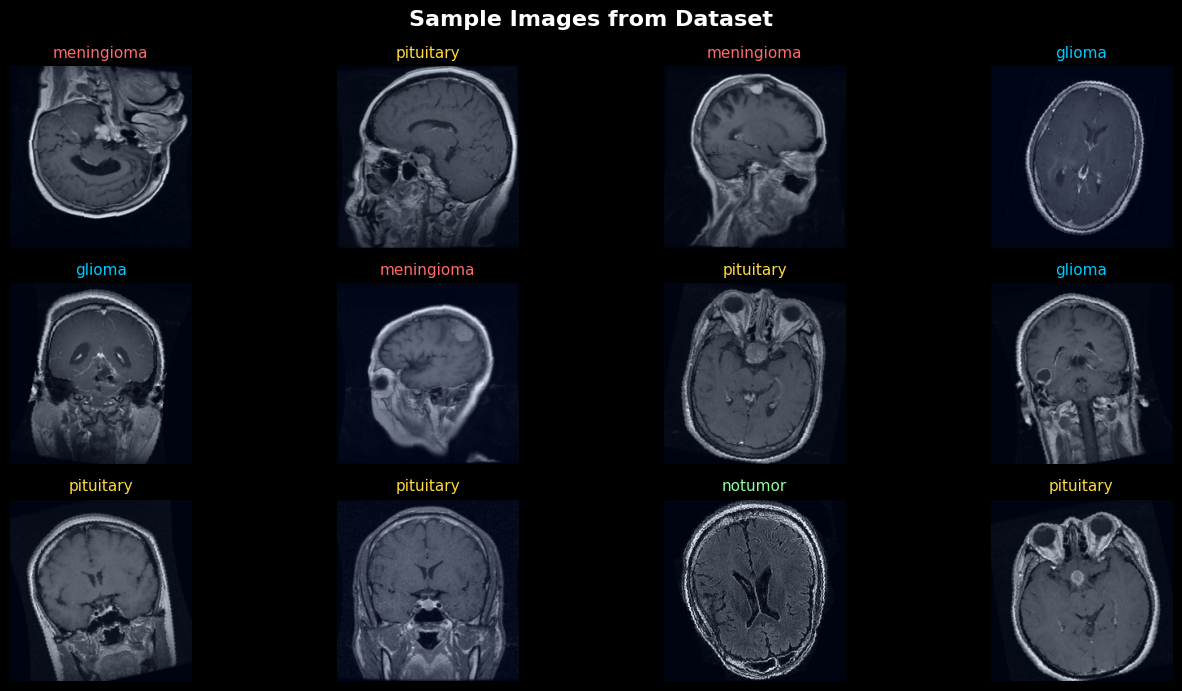

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('dark_background')
colors = ['#00C9FF', '#FF6B6B', '#92FE9D', '#FFD93D']

fig, axes = plt.subplots(3, 4, figsize=(14, 7))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')

axes_flat = axes.flatten()

for i in range(12):
    idx = np.random.randint(len(train_dataset))
    img, label = train_dataset[idx]
    img = img.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    axes_flat[i].imshow(img, cmap='gray')
    axes_flat[i].set_title(train_dataset.classes[label],
                           fontsize=11, color=colors[label])
    axes_flat[i].axis('off')

plt.tight_layout()
plt.show()

In [12]:
class brain_tumor(nn.Module):
  def __init__(self):
    super (brain_tumor , self).__init__()

    self.conv_layers = nn.Sequential(
        nn.Conv2d(3 , 32 , kernel_size=3 , padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32 , 64 , kernel_size=3 , padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64 , 128 , kernel_size=3 , padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(128 , 256 , kernel_size=3 , padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2,2)

    )

    self.fc_layers= nn.Sequential(
        nn.Flatten(),
        nn.Linear(256*14*14 , 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512 , 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128,4)
    )

  def forward(self,x):
    x = self.conv_layers(x)
    x = self.fc_layers(x)
    return x

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = brain_tumor().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr=0.001)

In [14]:
print(device)

cuda


In [15]:
epochs = 30
avg_train_loss = 0.0
avg_val_loss = 0.0
best_val_acc = 0.0

for epoch in range(epochs):
  train_loss = 0.0
  train_correct = 0
  model.train()
  for images , labels in train_loader:
    optimizer.zero_grad()
    images , labels = images.to(device) , labels.to(device)
    outputs = model(images )
    loss = criterion(outputs , labels )
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
    _,predicted = torch.max(outputs , 1)
    train_correct += (predicted == labels).sum().item()
  avg_train_loss = train_loss / len(train_loader)
  avg_train_acc = train_correct / len(train_dataset) * 100


  val_loss = 0.0
  val_correct = 0
  model.eval()
  with torch.no_grad():
    for images , labels in test_loader:
      images , labels = images.to(device) , labels.to(device)
      outputs = model(images)
      loss = criterion(outputs , labels )
      val_loss += loss.item()
      _,predicted = torch.max(outputs , 1)
      val_correct += (predicted == labels).sum().item()
  avg_val_loss = val_loss / len(test_loader)

  avg_val_acc = val_correct / len(test_dataset) * 100

  print(f"epoch -> {epoch+1}/{epochs} | train loss : {avg_train_loss:.4f} | train accuracy: {avg_train_acc:.2f} % | validation loss : {avg_val_loss:.4f} | validation accuracy : {avg_val_acc:.2f} %" )

  if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), 'best_modeltumor.pth')
        print(f" Best model saved! Val Acc: {best_val_acc:.2f}%")



epoch -> 1/30 | train loss : 1.3844 | train accuracy: 51.70 % | validation loss : 1.0460 | validation accuracy : 65.69 %
 Best model saved! Val Acc: 65.69%
epoch -> 2/30 | train loss : 0.7479 | train accuracy: 70.39 % | validation loss : 0.8506 | validation accuracy : 70.19 %
 Best model saved! Val Acc: 70.19%
epoch -> 3/30 | train loss : 0.6271 | train accuracy: 74.79 % | validation loss : 0.8325 | validation accuracy : 71.56 %
 Best model saved! Val Acc: 71.56%
epoch -> 4/30 | train loss : 0.5686 | train accuracy: 77.86 % | validation loss : 0.7942 | validation accuracy : 72.56 %
 Best model saved! Val Acc: 72.56%
epoch -> 5/30 | train loss : 0.5295 | train accuracy: 79.30 % | validation loss : 0.8327 | validation accuracy : 72.94 %
 Best model saved! Val Acc: 72.94%
epoch -> 6/30 | train loss : 0.4846 | train accuracy: 80.95 % | validation loss : 0.9272 | validation accuracy : 76.00 %
 Best model saved! Val Acc: 76.00%
epoch -> 7/30 | train loss : 0.4652 | train accuracy: 83.34 % | 

ACCURACY : 91.5
CLASSIFICATION REPORT : 
              precision    recall  f1-score   support

      glioma       0.97      0.77      0.86       400
  meningioma       0.89      0.91      0.90       400
     notumor       0.90      0.99      0.94       400
   pituitary       0.92      0.99      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.91      1600
weighted avg       0.92      0.92      0.91      1600



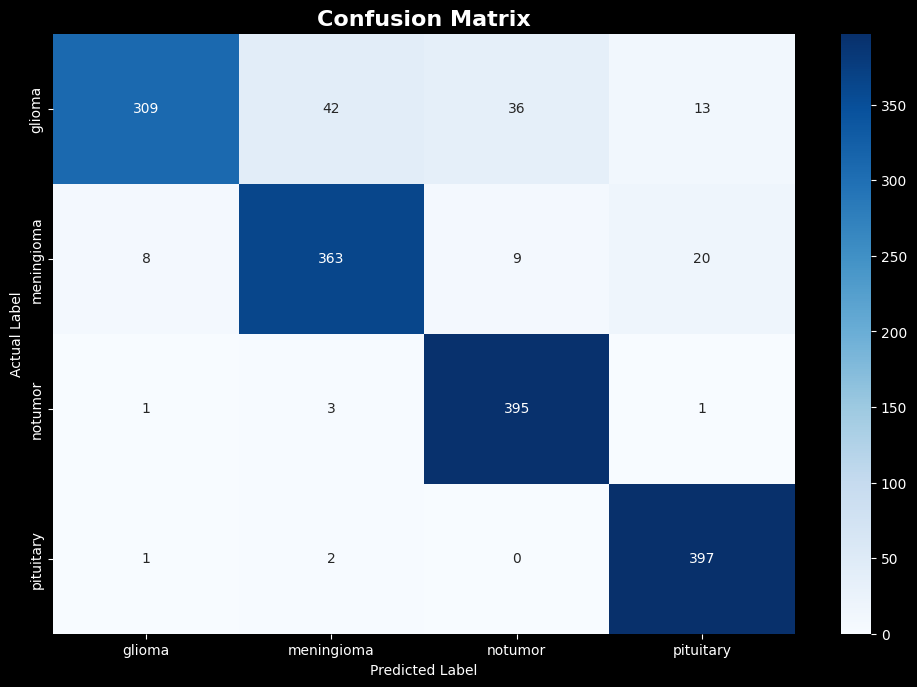

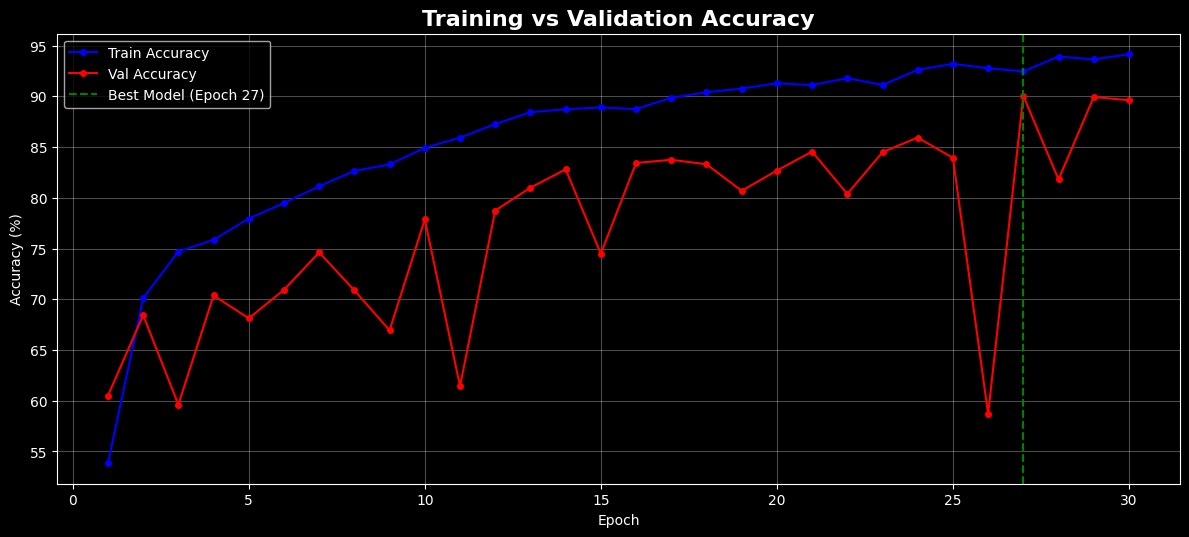

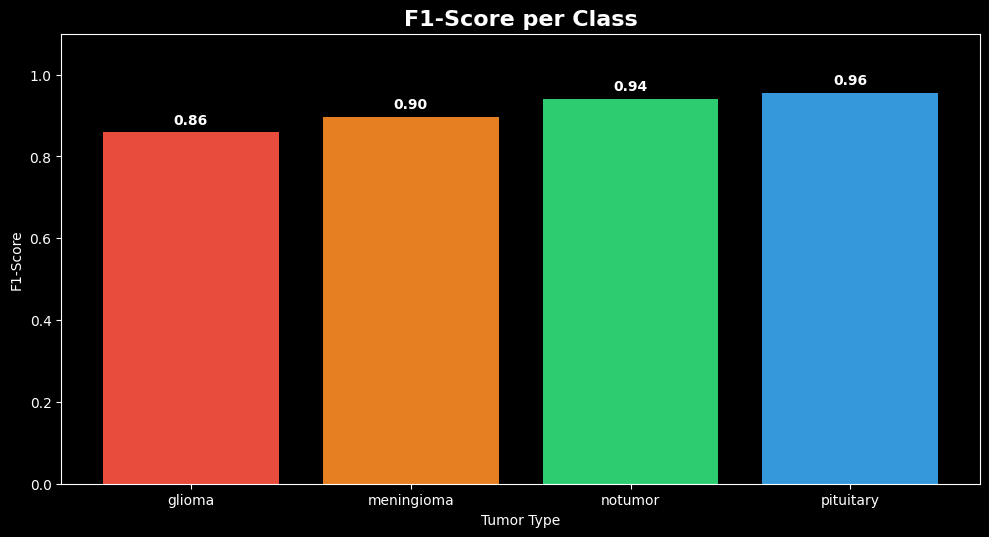

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.load_state_dict(torch.load("best_modeltumor.pth"))
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
  for images , labels in test_loader:
    images , labels = images.to(device) , labels.to(device)
    outputs = model(images)
    _,predictions = torch.max(outputs , 1)
    all_preds.extend(predictions.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).sum() / len(all_labels) * 100
print(f"ACCURACY : {accuracy}")

classes = test_dataset.classes
print("CLASSIFICATION REPORT : ")
print(classification_report(all_labels , all_preds , target_names=classes))

classes = test_dataset.classes

# ── 1. Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.subplots_adjust(top=0.9, bottom=0.15)
plt.show()

# ── 2. Training Curve ────────────────────────────────────────────

train_acc = [53.84, 70.11, 74.71, 75.86, 77.96, 79.48, 81.14, 82.66,
             83.29, 84.93, 85.93, 87.27, 88.45, 88.73, 88.91, 88.75,
             89.86, 90.41, 90.77, 91.29, 91.11, 91.80, 91.12, 92.62,
             93.20, 92.77, 92.46, 93.93, 93.64, 94.16]

val_acc  = [60.50, 68.44, 59.62, 70.38, 68.12, 70.94, 74.62, 70.88,
            66.94, 77.88, 61.44, 78.75, 81.00, 82.81, 74.50, 83.44,
            83.75, 83.31, 80.69, 82.69, 84.56, 80.38, 84.50, 85.94,
            83.94, 58.69, 90.06, 81.81, 89.94, 89.62]

epochs = range(1, 31)

plt.figure(figsize=(12, 6))
plt.plot(epochs, train_acc, 'b-o', markersize=4, label='Train Accuracy')
plt.plot(epochs, val_acc,   'r-o', markersize=4, label='Val Accuracy')
plt.axvline(x=27, color='green', linestyle='--', label='Best Model (Epoch 27)')
plt.title('Training vs Validation Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.subplots_adjust(top=0.9, bottom=0.15)
plt.show()

# ── 3. Per-Class F1 Score Bar Chart ─────────────────────────────
report = classification_report(all_labels, all_preds,
                                target_names=classes, output_dict=True)
f1_scores = [report[c]['f1-score'] for c in classes]

plt.figure(figsize=(10, 6))
bars = plt.bar(classes, f1_scores, color=['#e74c3c','#e67e22','#2ecc71','#3498db'])
plt.title('F1-Score per Class', fontsize=16, fontweight='bold')
plt.xlabel('Tumor Type')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('f1_scores.png', dpi=150)
plt.subplots_adjust(top=0.9, bottom=0.15)
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('confusion_matrix.png', '/content/drive/MyDrive/confusion_matrix.png')
shutil.copy('training_curve.png', '/content/drive/MyDrive/training_curve.png')
shutil.copy('f1_scores.png', '/content/drive/MyDrive/f1_scores.png')

In [ ]:
!git config --global user.email "jainishkumar724@gmail.com"
!git config --global user.name "JainishKumar12"

In [ ]:
%cd /content
!git init
!git remote add origin https://github.com/JainishKumar12/Brain-tumor-classification

In [ ]:
!git add brain_tumor_classification.ipynb
!git add confusion_matrix.png training_curve.png f1_scores.png
!git add README.md .gitignore
!git commit -m "Add notebook, graphs and README"
!git branch -M main
!git push -u origin main

In [ ]:
import shutil

# Copy notebook
shutil.copy('/content/drive/MyDrive/Colab Notebooks/brain_tumor.ipynb', '/content/brain_tumor.ipynb')

# Copy graphs (if saved to Drive earlier)
shutil.copy('/content/drive/MyDrive/confusion_matrix.png', '/content/confusion_matrix.png')
shutil.copy('/content/drive/MyDrive/training_curve.png', '/content/training_curve.png')
shutil.copy('/content/drive/MyDrive/f1_scores.png', '/content/f1_scores.png')

In [ ]:
%%writefile /content/README.md
# 🧠 Brain Tumor Classification using CNN
Add your readme content here

In [ ]:
%cd /content
!git add brain_tumor.ipynb confusion_matrix.png training_curve.png f1_scores.png README.md
!git commit -m "Add brain tumor classification project"
!git branch -M main
!git push https://github.com/JainishKumar12/Brain-tumor-classification.git